In [2]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

In [3]:
df = pd.read_csv("Data.csv")
df.head()

,AT,V,AP,RH,PE
0,14.96,41.76,1024.07,73.17,463.26
1,25.18,62.96,1020.04,59.08,444.37
2,5.11,39.40,1012.16,92.14,488.56
3,20.86,57.32,1010.24,76.64,446.48
4,10.82,37.50,1009.23,96.62,473.90


In [4]:
X = df.iloc[:,:4]
y = df.iloc[:,4]

In [5]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=0)

In [6]:
from sklearn.preprocessing import PolynomialFeatures
poly_reg = PolynomialFeatures(degree=4)
X_poly = poly_reg.fit_transform(X_train)

In [7]:
from sklearn.linear_model import LinearRegression
lin_reg = LinearRegression()
lin_reg.fit(X_poly, y_train)
y_pred = lin_reg.predict(poly_reg.fit_transform(X_test))

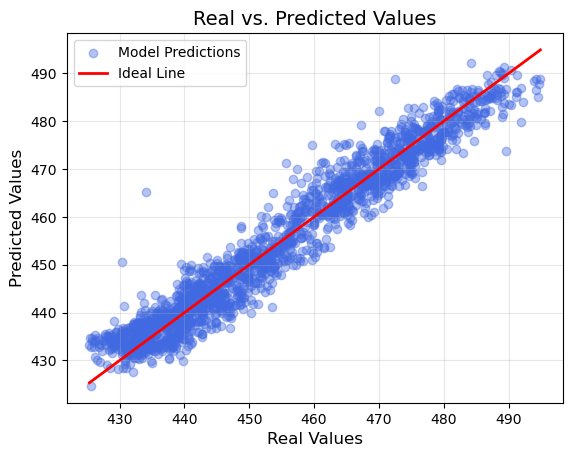

In [8]:
plt.scatter(y_test, y_pred, color='royalblue', alpha=0.4, label='Model Predictions')
ideal_line = np.linspace(y_test.min(), y_test.max(), 100)
plt.plot(ideal_line, ideal_line, color='red', linewidth=2, linestyle='-', label='Ideal Line')
plt.title('Real vs. Predicted Values', fontsize=14)
plt.xlabel('Real Values', fontsize=12)
plt.ylabel('Predicted Values', fontsize=12)
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

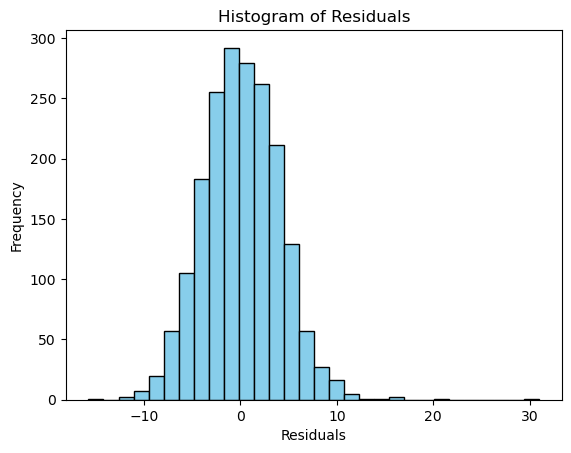

In [ ]:
residuals = y_pred - y_test
plt.hist(residuals, bins=30, color='skyblue', edgecolor='black')
plt.xlabel('Residuals')
plt.ylabel('Frequency')
plt.title('Histogram of Residuals')
plt.show()

In [9]:
from sklearn.metrics import r2_score, mean_absolute_error,mean_squared_error

print(f"r2_score: {r2_score(y_test, y_pred)}")
print(f"mean_absolute_error: {mean_absolute_error(y_test, y_pred)}")
print(f"mean_squared_error: {mean_squared_error(y_test, y_pred)}")
print(f"RMSE: {np.sqrt(mean_squared_error(y_test, y_pred))}")

y_test_mean = y_test.mean()
relative_mae = mean_absolute_error(y_test, y_pred) / y_test_mean
print(f"relative_mae: {relative_mae}({relative_mae * 100:.2f}%)")

r2_score: 0.9455261541792647
mean_absolute_error: 3.1434310159363266
mean_squared_error: 15.932937255596096
RMSE: 3.9916083544852063
relative_mae: 0.00691452949438108(0.69%)
